# Attention Concentration on Massive Activations — Llama-3.1-8B-Instruct

Reproduces Figure 5 from Sun, Chen, Kolter & Liu, *Massive Activations in Large Language Models* (COLM 2024):
pre-softmax attention-logit heatmaps (averaged over heads), before / right after / deep after massive activations
emerge, with the massive-activation token(s) annotated.

Loads Llama-3.1-8B-Instruct directly via `transformers` (no TransformerLens).

In [1]:
import gc
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer

print("torch", torch.__version__)
print("cuda available:", torch.cuda.is_available())

torch 2.2.2+cu121
cuda available: True


## Config

In [2]:
MODEL_PATH = "/home/samuel/research/llmattacks/llm-attacks/DIR/Llama-3.1-8B-Instruct"

# Paper's illustrative probe sentence. Swap in your own SALAD-Bench prompts once this is validated.
SEQ = "Summer is warm. Winter is cold."
ADD_SPECIAL_TOKENS = False  # matches the paper's official repo default for this style of figure

MA_ABS_THRESH = 100.0
MA_RATIO_THRESH = 1000.0

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.bfloat16 if torch.cuda.is_available() else torch.float32

## Load model and tokenizer

`attn_implementation="eager"` is required — SDPA/flash-attention kernels never materialize a (T, T) attention
matrix, so there is nothing to hook or inspect with those backends.

In [3]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    torch_dtype=DTYPE,
    device_map=DEVICE,
    attn_implementation="eager",
)
model.eval()

num_layers = model.config.num_hidden_layers
hidden_size = model.config.hidden_size
print(f"num_layers={num_layers}, hidden_size={hidden_size}, device={DEVICE}, dtype={DTYPE}")

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

num_layers=32, hidden_size=4096, device=cuda, dtype=torch.bfloat16


## Monkeypatch: capture pre-softmax attention logits

`output_attentions=True` in HF only returns *post-softmax* probabilities. The paper's Figure 5 plots the raw
`QK^T / sqrt(d) + causal_mask` logits, before softmax. We patch `eager_attention_forward` to stash those.

This depends on `transformers` internals and can break across versions, so the forward-pass cell below
automatically falls back to `log(post_softmax_probs)` if the patch doesn't produce output. The fallback preserves
the same relative concentration pattern (softmax is monotonic), just not the exact logit values / negative
baseline the paper's colorbar shows.

In [4]:
captured_logits = {}
_call_counter = {"i": 0}
_patch_installed = False

try:
    import transformers.models.llama.modeling_llama as llama_mod

    def _patched_eager_attention_forward(module, query, key, value, attention_mask, scaling, dropout=0.0, **kwargs):
        key_states = llama_mod.repeat_kv(key, module.num_key_value_groups)
        value_states = llama_mod.repeat_kv(value, module.num_key_value_groups)
        attn_weights = torch.matmul(query, key_states.transpose(2, 3)) * scaling
        if attention_mask is not None:
            causal_mask = attention_mask[:, :, :, : key_states.shape[-2]]
            attn_weights = attn_weights + causal_mask
        captured_logits[_call_counter["i"]] = attn_weights.detach().float().cpu()
        _call_counter["i"] += 1
        attn_probs = F.softmax(attn_weights, dim=-1, dtype=torch.float32).to(query.dtype)
        attn_probs = F.dropout(attn_probs, p=dropout, training=module.training)
        attn_output = torch.matmul(attn_probs, value_states).transpose(1, 2).contiguous()
        return attn_output, attn_probs

    llama_mod.eager_attention_forward = _patched_eager_attention_forward
    try:
        from transformers.modeling_utils import ALL_ATTENTION_FUNCTIONS
        ALL_ATTENTION_FUNCTIONS["eager"] = _patched_eager_attention_forward
    except Exception as e:
        print("Could not patch ALL_ATTENTION_FUNCTIONS registry (may still work if module patch is enough):", e)

    _patch_installed = True
    print("monkeypatch installed successfully")
except Exception as e:
    print("Monkeypatch setup failed, will use post-softmax fallback at forward-pass time. Error:", e)

Could not patch ALL_ATTENTION_FUNCTIONS registry (may still work if module patch is enough): cannot import name 'ALL_ATTENTION_FUNCTIONS' from 'transformers.modeling_utils' (/home/sajib/anaconda3/envs/geometric_audit/lib/python3.8/site-packages/transformers/modeling_utils.py)
monkeypatch installed successfully


## Tokenize and run forward pass

In [5]:
input_ids = tokenizer(SEQ, return_tensors="pt", add_special_tokens=ADD_SPECIAL_TOKENS).input_ids.to(DEVICE)
tokens_decoded = [tokenizer.decode(input_ids[0, i].item()) for i in range(input_ids.shape[1])]
print("tokens:", tokens_decoded)

captured_logits.clear()
_call_counter["i"] = 0

with torch.no_grad():
    out = model(input_ids, output_hidden_states=True, output_attentions=not _patch_installed)

hidden_states = out.hidden_states  # tuple, len = num_layers + 1

if _patch_installed and len(captured_logits) == num_layers:
    print(f"using true pre-softmax logits, captured {len(captured_logits)} layers, "
          f"shape per layer: {captured_logits[0].shape}")
else:
    if _patch_installed:
        print(f"WARNING: patch installed but only captured {len(captured_logits)}/{num_layers} layers "
              f"-- falling back to post-softmax probabilities. Re-running with output_attentions=True.")
        with torch.no_grad():
            out = model(input_ids, output_hidden_states=True, output_attentions=True)
        hidden_states = out.hidden_states
    captured_logits = {i: torch.log(a[0].float() + 1e-12).cpu() for i, a in enumerate(out.attentions)}
    print(f"using log(post-softmax probability) fallback, {len(captured_logits)} layers")

tokens: ['Summer', ' is', ' warm', '.', ' Winter', ' is', ' cold', '.']
using log(post-softmax probability) fallback, 32 layers


## Find where massive activations emerge, and which tokens carry them

In [6]:
def find_massive_activations(h, abs_thresh=MA_ABS_THRESH, ratio_thresh=MA_RATIO_THRESH):
    """h: (T, d) tensor for a single layer. Returns list of (token_idx, feat_idx, value), and layer median."""
    feat_abs = h.float().abs()
    med = feat_abs.median().item()
    mask = (feat_abs > abs_thresh) & (feat_abs > ratio_thresh * med)
    idxs = torch.nonzero(mask, as_tuple=False)
    results = [(int(t), int(i), feat_abs[t, i].item()) for t, i in idxs]
    results.sort(key=lambda r: -r[2])
    return results, med

stats = np.zeros((6, len(hidden_states)))
for l, h in enumerate(hidden_states):
    feat_abs = h[0].float().abs()
    flat_sorted, _ = torch.sort(feat_abs.flatten(), descending=True)
    stats[:5, l] = flat_sorted[:5].cpu().numpy()
    stats[5, l] = feat_abs.median().item()

emergence_layer = next(
    (l for l in range(1, len(hidden_states)) if stats[0, l] > MA_ABS_THRESH),
    None,
)
if emergence_layer is None:
    raise RuntimeError("No layer exceeded MA_ABS_THRESH -- inspect the `stats` array / lower the threshold.")

mas_emergence, layer_median = find_massive_activations(hidden_states[emergence_layer][0])
ma_token_positions = sorted(set(t for t, i, v in mas_emergence))

print(f"massive activations first exceed {MA_ABS_THRESH} at hidden_states index {emergence_layer} "
      f"(output of decoder layer {emergence_layer})")
print(f"layer median |activation| = {layer_median:.4f}")
print("massive-activation token positions:", ma_token_positions,
      [tokens_decoded[t] for t in ma_token_positions])
for t, i, v in mas_emergence:
    print(f"  token[{t}]=\"{tokens_decoded[t]}\"  feature_dim={i}  |activation|={v:.1f}")

massive activations first exceed 100.0 at hidden_states index 2 (output of decoder layer 2)
layer median |activation| = 0.0148
massive-activation token positions: [0] ['Summer']
  token[0]="Summer"  feature_dim=788  |activation|=242.0
  token[0]="Summer"  feature_dim=1384  |activation|=221.0
  token[0]="Summer"  feature_dim=4062  |activation|=219.0


## Plot: attention-logit heatmaps (paper style)

Causal mask shown in grey (upper triangle), no per-token axis labels (matches the paper's Figure 5/6 exactly),
massive-activation columns annotated with arrows. Three panels: one layer before emergence, right after
emergence, and a deep layer (avoiding the very last layer, where massive activations decay per the layer-sweep
plot).

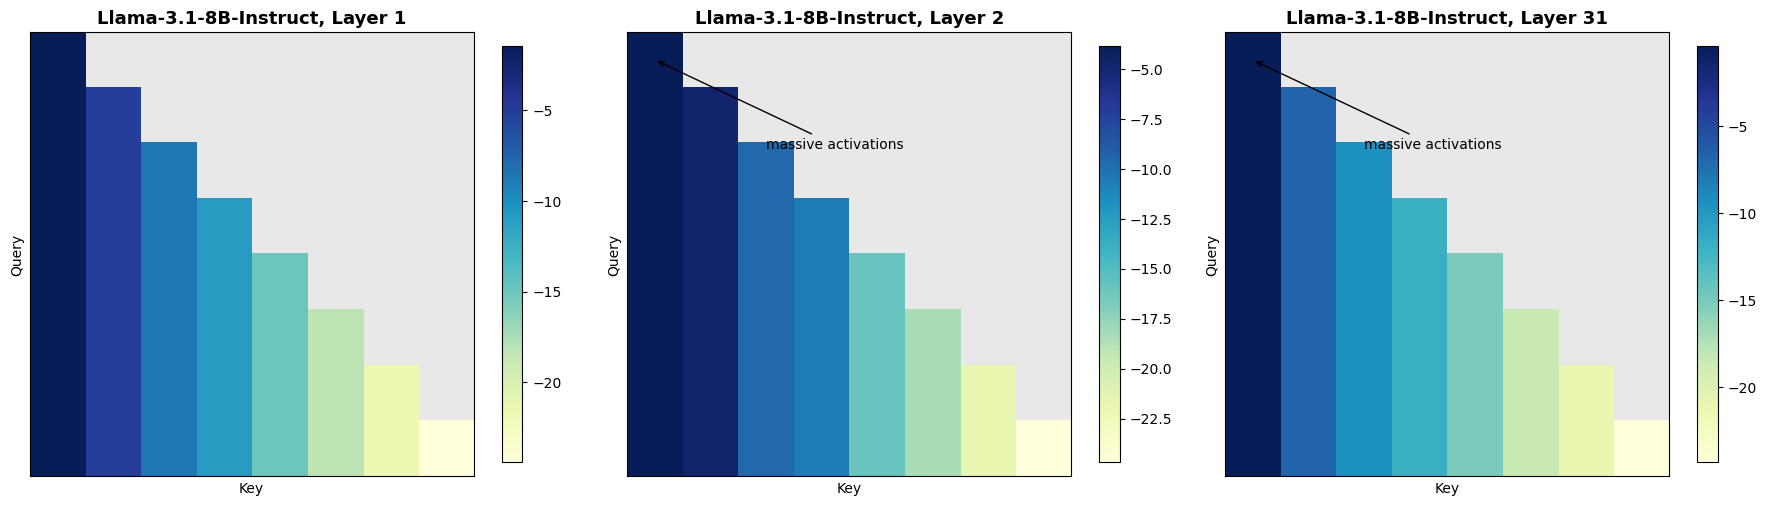

In [7]:
def plot_logit_heatmap(logits_2d, ax, title, highlight_cols=None):
    T = logits_2d.shape[0]
    masked = np.where(np.triu(np.ones((T, T), dtype=bool), k=1), np.nan, logits_2d)

    cmap = plt.cm.YlGnBu.copy()
    cmap.set_bad(color="#e8e8e8")
    im = ax.imshow(masked, cmap=cmap, aspect="equal")

    ax.set_xlabel("Key")
    ax.set_ylabel("Query")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=13, fontweight="bold")

    if highlight_cols:
        for j, col in enumerate(highlight_cols):
            ax.annotate(
                "massive activations" if j == 0 else "",
                xy=(col, col),
                xytext=(col + T * 0.25, T * 0.2),
                arrowprops=dict(arrowstyle="->", color="black"),
                fontsize=10,
            )
    plt.colorbar(im, ax=ax, shrink=0.8)
    return im


# captured_logits[l] corresponds to the attention INSIDE decoder layer l (0-indexed),
# whose output is hidden_states[l + 1].
before_idx = max(0, emergence_layer - 2)
after_idx = emergence_layer - 1
deep_idx = len(captured_logits) - 2  # avoid the very last layer, where MAs decay

layer_indices = sorted(set([before_idx, after_idx, deep_idx]))

fig, axes = plt.subplots(1, len(layer_indices), figsize=(6 * len(layer_indices), 5.5))
if len(layer_indices) == 1:
    axes = [axes]

for ax, idx in zip(axes, layer_indices):
    logits_avg = captured_logits[idx][0].mean(dim=0).cpu().numpy()  # average over heads
    plot_logit_heatmap(
        logits_avg,
        ax,
        f"Llama-3.1-8B-Instruct, Layer {idx + 1}",
        highlight_cols=ma_token_positions if idx >= after_idx else None,
    )

plt.tight_layout()
plt.savefig("llama31_8b_instruct_attention_concentration.png", dpi=200, bbox_inches="tight")
plt.show()

## Notes

- If the primary monkeypatch cell prints a warning about falling back, the plots still show the correct
  *concentration pattern* (softmax is monotonic), but the colorbar values are `log(probability)` rather than raw
  logits, so they won't numerically match the paper's colorbar scale — only the pattern is comparable, not the
  absolute numbers.
- To match Figure 6's per-token labels instead of the cleaner unlabeled style of Figure 5, pass
  `tokens_decoded` into `set_xticklabels`/`set_yticklabels` in `plot_logit_heatmap`.
- `MA_ABS_THRESH` / `MA_RATIO_THRESH` follow the paper's own loose definition (>100 and >~1000x median). If no
  layer is detected, first check the layerwise `stats` array — Llama-3.1-8B-Instruct's massive activations were
  found to plateau around 200-300 in earlier analysis, comfortably above 100, so this should trigger normally.